# GO Cellular Component Ground Truth Collection
Build subcellular co-localization ground truth from Gene Ontology CC annotations for the protein embedding benchmark.

GO CC captures a middle ground between physical interaction (CORUM) and functional association (KEGG/Reactome): proteins sharing a subcellular compartment are spatially co-localized, which is necessary but not sufficient for physical interaction.

**Key decisions in this notebook:**
1. Which evidence codes to include (experimental only vs. all)
2. How to handle GO term specificity (filter out broad terms like 'cytoplasm')
3. Whether to propagate annotations up the ontology

Same matrix structure as KEGG, Reactome, and CORUM notebooks.

In [1]:
from _common import CACHE, FASTA, fetch, require_manual  # noqa: F401
import requests
import gzip
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
from matplotlib.patches import Patch

# 1. Download and parse the GAF file

The GOA human annotation file (GAF format) contains all GO annotations for human proteins.  
Each line is a protein–GO term association with an evidence code.

GAF columns we care about:
- Col 1 (DB): database, e.g. `UniProtKB`
- Col 2 (DB Object ID): UniProt accession
- Col 4 (Qualifier): `located_in`, `part_of`, `is_active_in`, or NOT qualifiers
- Col 5 (GO ID): GO term, e.g. `GO:0005634`
- Col 7 (Evidence Code): e.g. `IDA`, `IEA`, `TAS`
- Col 9 (Aspect): `C` for Cellular Component

In [2]:
# Download the human GAF file
url = "http://current.geneontology.org/annotations/goa_human.gaf.gz"
print(f"Fetching: {url}")
resp = requests.get(url, timeout=120)
resp.raise_for_status()
print(f"Downloaded {len(resp.content) / 1e6:.1f} MB (compressed)")

# Decompress and parse
content = gzip.decompress(resp.content).decode('utf-8')
lines = content.strip().split('\n')
print(f"Total lines: {len(lines):,}")
print(f"Comment lines: {sum(1 for l in lines if l.startswith('!')):,}")

Fetching: http://current.geneontology.org/annotations/goa_human.gaf.gz
Downloaded 14.8 MB (compressed)
Total lines: 880,967
Comment lines: 39


In [3]:
# Parse GAF into a dataframe
gaf_columns = [
    'db', 'db_object_id', 'db_object_symbol', 'qualifier', 'go_id',
    'db_reference', 'evidence_code', 'with_from', 'aspect',
    'db_object_name', 'db_object_synonym', 'db_object_type',
    'taxon', 'date', 'assigned_by', 'annotation_extension', 'gene_product_form_id'
]

rows = []
for line in lines:
    if line.startswith('!'):
        continue
    parts = line.split('\t')
    if len(parts) >= 15:
        rows.append(parts[:17] if len(parts) >= 17 else parts + [''] * (17 - len(parts)))

df_gaf = pd.DataFrame(rows, columns=gaf_columns)
print(f"Total annotations: {len(df_gaf):,}")
print(f"\nAspect distribution:")
print(df_gaf['aspect'].value_counts())
print(f"\nDB distribution:")
print(df_gaf['db'].value_counts().head())

Total annotations: 880,928

Aspect distribution:
aspect
F    415857
C    260470
P    204601
Name: count, dtype: int64

DB distribution:
db
UniProtKB        833037
RNAcentral        38226
ComplexPortal      9665
Name: count, dtype: int64


In [4]:
# Filter to Cellular Component only
df_cc = df_gaf[df_gaf['aspect'] == 'C'].copy()
print(f"Cellular Component annotations: {len(df_cc):,}")
print(f"Unique proteins: {df_cc['db_object_id'].nunique():,}")
print(f"Unique GO CC terms: {df_cc['go_id'].nunique():,}")

# Exclude NOT qualifiers (negative annotations)
not_mask = df_cc['qualifier'].str.contains('NOT', case=False, na=False)
print(f"\nNOT annotations (excluded): {not_mask.sum():,}")
df_cc = df_cc[~not_mask].copy()
print(f"After excluding NOT: {len(df_cc):,}")

Cellular Component annotations: 260,470
Unique proteins: 32,447
Unique GO CC terms: 1,841

NOT annotations (excluded): 255
After excluding NOT: 260,215


# 2. Decision: Evidence codes

GO evidence codes indicate how reliable an annotation is:

**Experimental evidence** (highest confidence):
- `EXP` (Inferred from Experiment)
- `IDA` (Inferred from Direct Assay)
- `IPI` (Inferred from Physical Interaction)
- `IMP` (Inferred from Mutant Phenotype)
- `IGI` (Inferred from Genetic Interaction)
- `IEP` (Inferred from Expression Pattern)
- `HDA` (Inferred from High Throughput Direct Assay)
- `HMP`, `HGI`, `HEP` (high-throughput variants)

**Curated non-experimental:**
- `TAS` (Traceable Author Statement)
- `NAS` (Non-traceable Author Statement)
- `IC` (Inferred by Curator)
- `ISS`, `ISO`, `ISA`, `ISM` (sequence similarity-based)

**Electronic** (lowest confidence):
- `IEA` (Inferred from Electronic Annotation) — bulk-assigned, noisy

Let's see the distribution and decide.

In [5]:
print("Evidence code distribution (CC annotations):")
ev_counts = df_cc['evidence_code'].value_counts()
for code, count in ev_counts.items():
    print(f"  {code:<5} {count:>8,} ({count/len(df_cc)*100:.1f}%)")

# Group by category
experimental = {'EXP', 'IDA', 'IPI', 'IMP', 'IGI', 'IEP', 'HDA', 'HMP', 'HGI', 'HEP'}
curated = {'TAS', 'NAS', 'IC', 'ISS', 'ISO', 'ISA', 'ISM', 'IBA', 'IBD', 'IKR', 'IRD', 'RCA'}
electronic = {'IEA'}

n_exp = df_cc[df_cc['evidence_code'].isin(experimental)].shape[0]
n_cur = df_cc[df_cc['evidence_code'].isin(curated)].shape[0]
n_ele = df_cc[df_cc['evidence_code'].isin(electronic)].shape[0]

print(f"\nSummary:")
print(f"  Experimental: {n_exp:>8,} ({n_exp/len(df_cc)*100:.1f}%)")
print(f"  Curated:      {n_cur:>8,} ({n_cur/len(df_cc)*100:.1f}%)")
print(f"  Electronic:   {n_ele:>8,} ({n_ele/len(df_cc)*100:.1f}%)")

# How many unique proteins per category?
print(f"\nUnique proteins:")
print(f"  Experimental only: {df_cc[df_cc['evidence_code'].isin(experimental)]['db_object_id'].nunique():,}")
print(f"  Exp + Curated:     {df_cc[df_cc['evidence_code'].isin(experimental | curated)]['db_object_id'].nunique():,}")
print(f"  All (incl. IEA):   {df_cc['db_object_id'].nunique():,}")

Evidence code distribution (CC annotations):
  TAS     89,807 (34.5%)
  IEA     78,094 (30.0%)
  IDA     44,960 (17.3%)
  IBA     23,071 (8.9%)
  HDA      7,708 (3.0%)
  ISS      7,167 (2.8%)
  NAS      5,204 (2.0%)
  IMP      1,191 (0.5%)
  HTP      1,134 (0.4%)
  ISA        728 (0.3%)
  IC         479 (0.2%)
  IPI        399 (0.2%)
  IGI         91 (0.0%)
  ND          90 (0.0%)
  EXP         75 (0.0%)
  RCA         11 (0.0%)
  ISO          4 (0.0%)
  ISM          2 (0.0%)

Summary:
  Experimental:   54,424 (20.9%)
  Curated:       126,473 (48.6%)
  Electronic:     78,094 (30.0%)

Unique proteins:
  Experimental only: 13,248
  Exp + Curated:     19,381
  All (incl. IEA):   32,447


In [6]:
# DECISION: include experimental + curated, exclude IEA
# Rationale: IEA is bulk electronic annotation and noisy
# Exp + curated gives good coverage while maintaining quality
# Change this if you want a different filter!

allowed_evidence = experimental | curated
df_cc_filtered = df_cc[df_cc['evidence_code'].isin(allowed_evidence)].copy()

print(f"After evidence filtering (no IEA): {len(df_cc_filtered):,} annotations")
print(f"Unique proteins: {df_cc_filtered['db_object_id'].nunique():,}")
print(f"Unique GO CC terms: {df_cc_filtered['go_id'].nunique():,}")

After evidence filtering (no IEA): 180,897 annotations
Unique proteins: 19,381
Unique GO CC terms: 1,679


# 3. Decision: Term specificity filter

Very broad GO CC terms (e.g. 'cytoplasm', 'membrane', 'nucleus') annotate thousands of proteins. Two proteins sharing 'cytoplasm' tells us almost nothing — half the proteome is cytoplasmic.

We filter by the number of proteins annotated to each term:
- Too many proteins → term is too broad, not informative
- Too few proteins → might be noisy or too specific

Let's explore the distribution and pick a max size cutoff.

In [7]:
# Build GO term → set of proteins (before filtering)
term_to_proteins_raw = defaultdict(set)
for _, row in df_cc_filtered.iterrows():
    term_to_proteins_raw[row['go_id']].add(row['db_object_id'])
term_to_proteins_raw = dict(term_to_proteins_raw)

term_sizes = {t: len(p) for t, p in term_to_proteins_raw.items()}
sizes_list = sorted(term_sizes.values())

print(f"GO CC terms: {len(term_sizes)}")
print(f"\nTerm size distribution (proteins per term):")
print(f"  Min: {sizes_list[0]}, Median: {sizes_list[len(sizes_list)//2]}, "
      f"Mean: {np.mean(sizes_list):.1f}, Max: {sizes_list[-1]}")

print(f"\n20 largest terms:")
for term, size in sorted(term_sizes.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"  {term}: {size:>5} proteins")

GO CC terms: 1679

Term size distribution (proteins per term):
  Min: 1, Median: 4, Mean: 41.2, Max: 5737

20 largest terms:
  GO:0005634:  5737 proteins
  GO:0005886:  4970 proteins
  GO:0005829:  4881 proteins
  GO:0005737:  4594 proteins
  GO:0005654:  3554 proteins
  GO:0016020:  2593 proteins
  GO:0005576:  2510 proteins
  GO:0070062:  2182 proteins
  GO:0000785:  1265 proteins
  GO:0005739:  1228 proteins
  GO:0005783:   973 proteins
  GO:0005789:   945 proteins
  GO:0005794:   801 proteins
  GO:0005730:   670 proteins
  GO:0032991:   584 proteins
  GO:0000139:   528 proteins
  GO:0009986:   516 proteins
  GO:0005813:   476 proteins
  GO:0005743:   459 proteins
  GO:0048471:   454 proteins


In [8]:
# Explore different max_size cutoffs
cutoffs = [50, 100, 200, 500, 1000, None]

print(f"{'Max size':<12} {'Terms kept':>12} {'Terms removed':>14} {'Proteins covered':>18}")
print("-" * 60)
for cutoff in cutoffs:
    if cutoff is None:
        kept_terms = term_to_proteins_raw
        label = "No filter"
    else:
        kept_terms = {t: p for t, p in term_to_proteins_raw.items() if len(p) <= cutoff}
        label = f"≤ {cutoff}"
    
    all_prots = set().union(*kept_terms.values()) if kept_terms else set()
    removed = len(term_to_proteins_raw) - len(kept_terms)
    print(f"{label:<12} {len(kept_terms):>12,} {removed:>14,} {len(all_prots):>18,}")

Max size       Terms kept  Terms removed   Proteins covered
------------------------------------------------------------
≤ 50                1,514            165              6,347
≤ 100               1,592             87              8,261
≤ 200               1,637             42              9,917
≤ 500               1,662             17             11,595
≤ 1000              1,669             10             12,750
No filter           1,679              0             19,381


In [9]:
# DECISION: filter out terms with > 500 annotated proteins
# Rationale: keeps specific compartments, removes broad terms like 'cytoplasm'
# As mentioned in the lab notebook: "filter to sufficiently specific GO terms"
# Change MAX_TERM_SIZE if you want a different cutoff!

MAX_TERM_SIZE = 500

term_to_proteins = {t: p for t, p in term_to_proteins_raw.items() if len(p) <= MAX_TERM_SIZE}

removed_terms = {t: p for t, p in term_to_proteins_raw.items() if len(p) > MAX_TERM_SIZE}
print(f"Removed {len(removed_terms)} broad terms (>{MAX_TERM_SIZE} proteins):")
for t, p in sorted(removed_terms.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"  {t}: {len(p)} proteins")

print(f"\nKept {len(term_to_proteins)} GO CC terms")
all_cc_proteins = set().union(*term_to_proteins.values())
print(f"Covering {len(all_cc_proteins):,} unique proteins")

Removed 17 broad terms (>500 proteins):
  GO:0005634: 5737 proteins
  GO:0005886: 4970 proteins
  GO:0005829: 4881 proteins
  GO:0005737: 4594 proteins
  GO:0005654: 3554 proteins
  GO:0016020: 2593 proteins
  GO:0005576: 2510 proteins
  GO:0070062: 2182 proteins
  GO:0000785: 1265 proteins
  GO:0005739: 1228 proteins
  GO:0005783: 973 proteins
  GO:0005789: 945 proteins
  GO:0005794: 801 proteins
  GO:0005730: 670 proteins
  GO:0032991: 584 proteins
  GO:0000139: 528 proteins
  GO:0009986: 516 proteins

Kept 1662 GO CC terms
Covering 11,595 unique proteins


# 4. Build protein → GO CC term sets and evaluate thresholds

Note: we are using **direct annotations only** (no propagation up the ontology).  
The GAF file already contains the most specific annotations; propagating up would just add the broad terms we're filtering out anyway.

In [10]:
# protein → set of GO CC term IDs
protein_to_cc_set = defaultdict(set)
for term, prots in term_to_proteins.items():
    for p in prots:
        protein_to_cc_set[p].add(term)
protein_to_cc_set = dict(protein_to_cc_set)

print(f"Proteins with CC annotations: {len(protein_to_cc_set):,}")

# Terms per protein
terms_per_prot = sorted([len(v) for v in protein_to_cc_set.values()])
print(f"\nCC terms per protein:")
print(f"  Min: {terms_per_prot[0]}, Median: {terms_per_prot[len(terms_per_prot)//2]}, "
      f"Mean: {np.mean(terms_per_prot):.1f}, Max: {terms_per_prot[-1]}")

Proteins with CC annotations: 11,595

CC terms per protein:
  Min: 1, Median: 2, Mean: 2.6, Max: 33


In [11]:
# Compute shared CC term counts using dot product
cc_protein_list = sorted(protein_to_cc_set.keys())
all_cc_terms_sorted = sorted(set().union(*protein_to_cc_set.values()))
cc_to_idx = {t: i for i, t in enumerate(all_cc_terms_sorted)}

n_cc = len(cc_protein_list)
print(f"GO CC proteins: {n_cc}")
print(f"GO CC terms: {len(all_cc_terms_sorted)}")
print(f"Unique pairs: {n_cc * (n_cc - 1) // 2:,}")

membership = np.zeros((n_cc, len(all_cc_terms_sorted)), dtype=np.float32)
for i, prot in enumerate(cc_protein_list):
    for term in protein_to_cc_set[prot]:
        membership[i, cc_to_idx[term]] = 1.0

print(f"Membership matrix: {membership.shape}")
print(f"Computing shared CC term counts...")
shared_counts = membership @ membership.T
print("Done!")

GO CC proteins: 11595
GO CC terms: 1662
Unique pairs: 67,216,215
Membership matrix: (11595, 1662)
Computing shared CC term counts...
Done!


In [12]:
# Shared CC term distribution
upper_tri = shared_counts[np.triu_indices(n_cc, k=1)]
total_pairs = len(upper_tri)

print(f"Total evaluable pairs (both in GO CC): {total_pairs:,}")
print(f"Pairs sharing 0 CC terms: {np.sum(upper_tri == 0):,}")
print(f"\nShared CC term count distribution (first 20):")
for i in range(min(20, int(upper_tri.max()) + 1)):
    count = np.sum(upper_tri == i)
    if count > 0:
        print(f"  {i:>3} shared terms: {count:>12,} pairs ({count/total_pairs*100:.2f}%)")

print(f"\n  Max shared CC terms: {int(upper_tri.max())}")

Total evaluable pairs (both in GO CC): 67,216,215
Pairs sharing 0 CC terms: 65,432,354

Shared CC term count distribution (first 20):
    0 shared terms:   65,432,354 pairs (97.35%)
    1 shared terms:    1,631,647 pairs (2.43%)
    2 shared terms:      127,254 pairs (0.19%)
    3 shared terms:       19,255 pairs (0.03%)
    4 shared terms:        3,933 pairs (0.01%)
    5 shared terms:        1,099 pairs (0.00%)
    6 shared terms:          328 pairs (0.00%)
    7 shared terms:          113 pairs (0.00%)
    8 shared terms:           74 pairs (0.00%)
    9 shared terms:          101 pairs (0.00%)
   10 shared terms:           24 pairs (0.00%)
   11 shared terms:           11 pairs (0.00%)
   12 shared terms:            1 pairs (0.00%)
   13 shared terms:            5 pairs (0.00%)
   14 shared terms:            3 pairs (0.00%)
   15 shared terms:            4 pairs (0.00%)
   16 shared terms:            6 pairs (0.00%)
   17 shared terms:            2 pairs (0.00%)
   18 shared terms:

# 5. Build the ground truth matrix

- `1` = positive (share ≥ 1 CC term, both annotated)
- `0` = negative (share 0 CC terms, both annotated)
- `NaN` = at least one protein not annotated to any (filtered) GO CC term

Proteins ordered alphabetically — same order as KEGG, Reactome, CORUM matrices.

In [13]:
from Bio import SeqIO

fasta_path = FASTA

protein_sequences = {}
for record in SeqIO.parse(fasta_path, 'fasta'):
    protein_id = record.id.split('|')[1]
    protein_sequences[protein_id] = str(record.seq)

all_proteins = list(protein_sequences.keys())
all_proteins_sorted = sorted(all_proteins)
n = len(all_proteins_sorted)
prot_to_idx = {p: i for i, p in enumerate(all_proteins_sorted)}

print(f"Total proteins: {n}")
print(f"Matrix shape: {n} x {n}")

Total proteins: 20372
Matrix shape: 20372 x 20372


In [14]:
# Check overlap
cc_set = set(protein_to_cc_set.keys())
fasta_set = set(all_proteins)

in_both = cc_set & fasta_set
cc_only = cc_set - fasta_set

print(f"GO CC proteins: {len(cc_set):,}")
print(f"In both GO CC and FASTA: {len(in_both):,}")
print(f"In GO CC only (not in FASTA): {len(cc_only):,}")

if cc_only:
    print(f"\nSample CC-only IDs: {sorted(cc_only)[:10]}")

GO CC proteins: 11,595
In both GO CC and FASTA: 11,058
In GO CC only (not in FASTA): 537

Sample CC-only IDs: ['A0A075B6U6', 'A0A075B734', 'A0A075B7D4', 'A0A087X1C1', 'A0A0C4DH90', 'A0A0G2JRQ6', 'A0A140TA62', 'A0A1B0GTE1', 'A0A1B0GTQ1', 'A0A1B0GVM2']


In [15]:
# Initialize all NaN
gocc_matrix = np.full((n, n), np.nan, dtype=np.float32)

# Filter to GO CC proteins in our FASTA
cc_in_fasta = sorted([p for p in protein_to_cc_set.keys() if p in prot_to_idx])
cc_indices = np.array([prot_to_idx[p] for p in cc_in_fasta])

print(f"GO CC proteins in our vocabulary: {len(cc_indices)} / {n}")

# Set all CC×CC pairs to 0
gocc_matrix[np.ix_(cc_indices, cc_indices)] = 0.0
print("Set all GO_CC×GO_CC pairs to 0 (negative)")

GO CC proteins in our vocabulary: 11058 / 20372
Set all GO_CC×GO_CC pairs to 0 (negative)


In [16]:
# Set positives: pairs sharing ≥ 1 CC term
membership_fasta = np.zeros((len(cc_in_fasta), len(all_cc_terms_sorted)), dtype=np.float32)
for i, prot in enumerate(cc_in_fasta):
    for term in protein_to_cc_set[prot]:
        membership_fasta[i, cc_to_idx[term]] = 1.0

shared = membership_fasta @ membership_fasta.T

full_indices = np.array([prot_to_idx[p] for p in cc_in_fasta])

pos_i, pos_j = np.where(shared >= 1)
mask = pos_i != pos_j
pos_i, pos_j = pos_i[mask], pos_j[mask]

gocc_matrix[full_indices[pos_i], full_indices[pos_j]] = 1.0
print(f"Set {len(pos_i):,} positive entries (both directions)")

Set 3,387,396 positive entries (both directions)


In [17]:
# Set diagonal to NaN
np.fill_diagonal(gocc_matrix, np.nan)

# Verify counts
upper = gocc_matrix[np.triu_indices(n, k=1)]
n_pos = np.nansum(upper == 1)
n_neg = np.nansum(upper == 0)
n_nan = np.sum(np.isnan(upper))

print(f"Upper triangle counts:")
print(f"  Positive (1): {int(n_pos):>12,}")
print(f"  Negative (0): {int(n_neg):>12,}")
print(f"  NaN:          {int(n_nan):>12,}")
print(f"  Total:        {len(upper):>12,}")
print(f"\n  Pos/Neg ratio: {n_pos/n_neg:.6f}")
print(f"  Matrix is symmetric: {np.allclose(gocc_matrix, gocc_matrix.T, equal_nan=True)}")

Upper triangle counts:
  Positive (1):    1,693,698
  Negative (0):   59,440,455
  NaN:           146,364,853
  Total:         207,499,006

  Pos/Neg ratio: 0.028494
  Matrix is symmetric: True


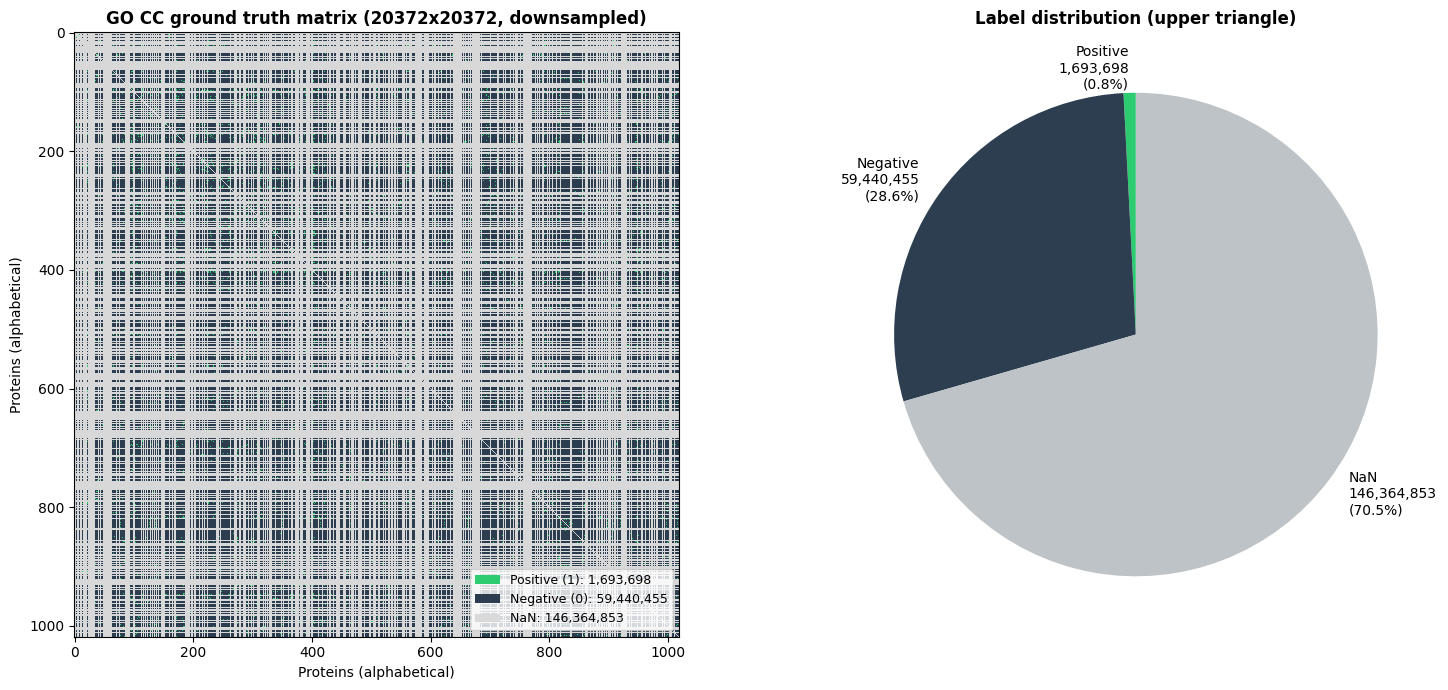

In [18]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

step = max(1, n // 1000)
display_matrix = gocc_matrix[::step, ::step]

rgb = np.zeros((*display_matrix.shape, 3), dtype=np.float32)
nan_mask = np.isnan(display_matrix)
neg_mask = display_matrix == 0
pos_mask = display_matrix == 1

rgb[nan_mask] = [0.85, 0.85, 0.85]
rgb[neg_mask] = [0.17, 0.24, 0.31]
rgb[pos_mask] = [0.18, 0.80, 0.44]

axes[0].imshow(rgb, aspect='equal', interpolation='nearest')
axes[0].set_title(f"GO CC ground truth matrix ({n}x{n}, downsampled)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Proteins (alphabetical)")
axes[0].set_ylabel("Proteins (alphabetical)")

legend_elements = [
    Patch(facecolor=[0.18, 0.80, 0.44], label=f'Positive (1): {int(n_pos):,}'),
    Patch(facecolor=[0.17, 0.24, 0.31], label=f'Negative (0): {int(n_neg):,}'),
    Patch(facecolor=[0.85, 0.85, 0.85], label=f'NaN: {int(n_nan):,}'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

sizes_plot = [int(n_pos), int(n_neg), int(n_nan)]
labels = [f'Positive\n{int(n_pos):,}\n({n_pos/len(upper)*100:.1f}%)',
          f'Negative\n{int(n_neg):,}\n({n_neg/len(upper)*100:.1f}%)',
          f'NaN\n{int(n_nan):,}\n({n_nan/len(upper)*100:.1f}%)']
colors = ['#2ecc71', '#2c3e50', '#bdc3c7']

axes[1].pie(sizes_plot, labels=labels, colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Label distribution (upper triangle)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
from pathlib import Path
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth

# save_ppi_ground_truth stores only the positives and the covered-protein
# universe (~36x smaller, reconstructs the dense matrix exactly) and will
# not replace an existing file: published results are pinned to the
# matrices in reference/, and these source databases change over time.
# save
import os

save_ppi_ground_truth(
    path=Path(GT_DIR_DEFAULT) / "gocc_ground_truth_matrix.npz",
    matrix=gocc_matrix,
    overwrite=False,   # True re-pins the published matrix; every result
                       # and figure derived from it must be regenerated too
)

with open("gocc_ground_truth_proteins.tsv", "w") as f:
    f.write("idx\tprotein\n")
    for i, p in enumerate(all_proteins_sorted):
        f.write(f"{i}\t{p}\n")

npz_size = os.path.getsize("gocc_ground_truth_matrix.npz") / 1e6
print(f"Saved gocc_ground_truth_matrix.npz ({npz_size:.1f} MB)")
print(f"Saved gocc_ground_truth_proteins.tsv")
print(f"\nParameters used:")
print(f"  Evidence codes: experimental + curated (no IEA)")
print(f"  Max term size: {MAX_TERM_SIZE} proteins")
print(f"  Annotation propagation: none (direct annotations only)")
print(f"  Threshold: ≥1 shared CC term")
print(f"\nTo load later:")
print(f"  matrix = np.load('gocc_ground_truth_matrix.npz')['matrix']")
print(f"  # shape ({n}, {n}), values: 0, 1, NaN")

Saved gocc_ground_truth_matrix.npz (60.7 MB)
Saved gocc_ground_truth_proteins.tsv

Parameters used:
  Evidence codes: experimental + curated (no IEA)
  Max term size: 500 proteins
  Annotation propagation: none (direct annotations only)
  Threshold: ≥1 shared CC term

To load later:
  matrix = np.load('gocc_ground_truth_matrix.npz')['matrix']
  # shape (20372, 20372), values: 0, 1, NaN
